# Homework #6

- Select not less than 9 predictors. Out of them at least 3 predictors should be
categorical.
- Conduct PCA using all interval or ratio scale predictors. Evaluate the applicability of PCA (KMO, explained cumulative variance, communalities).
- Describe each component based on the rotated principal component loading matrix, try to name it (it’s very important here to describe what each component means and what it evaluates). Save components as new variables in the original dataset. If PCA is not applicable, please explain why.
- Formulate research hypotheses which will be verified during the data analysis.
- Build a binary logistic regression model. Dependent variable is “y”. Predictors are
original variables and principal components (if PCA was applicable).
- Specify the regression equation (at least the linear part of it).
- Assess the goodness-of-fit of the model.
- Describe the relationships between each predictor and dependent variable in
detail. This is very important point of the task. We should understand clearly from the analysis which predictors influence the choice of the clients and how.
- Perform the model diagnostics.
- Make final conclusions about the results of analysis.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank-additional-full.csv', sep=';')

## Dataset Description

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
for t in df.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

Type: int64
['age' 'duration' 'campaign' 'pdays' 'previous']

Type: object
['job' 'marital' 'education' 'default' 'housing' 'loan' 'contact' 'month'
 'day_of_week' 'poutcome' 'y']

Type: float64
['emp.var.rate' 'cons.price.idx' 'cons.conf.idx' 'euribor3m' 'nr.employed']



In [ ]:
missing = (df.isna().sum() / len(df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)
missing = pd.DataFrame({'Percent of missing values' : missing})
missing

,Percent of missing values


## Task content

### Selected Variables

**Categorical Variables:**
- Poutcome
- Marital
- Education

**Interval / Ratio Scale Variables:**
- Age
- Duration
- Pdays
- Previous
- Euribor3m
- Nr.employed

In [ ]:
df['poutcome'].value_counts() # reference group: nonexistent

,count
poutcome,
nonexistent,35563
failure,4252
success,1373


In [ ]:
df['marital'].value_counts() # reference group: married

,count
marital,
married,24928
single,11568
divorced,4612
unknown,80


In [ ]:
df['education'].value_counts() # reference group: high.school

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [ ]:
# Remove tiny groups of data
cleared_df = df[(df['marital'] != 'unknown') & (df['education'] != 'unknown') & (df['education'] != 'illiterate')]

# Covert 'y' column to binary values
cleared_df['y'] = cleared_df['y'].map({'yes': 1, 'no': 0})

# Convert categorical variables to dummy
columns_to_dummies = ['poutcome', 'marital', 'education']
df_dummies = pd.get_dummies(cleared_df, columns=columns_to_dummies, dtype=int)

df_dummies.head()

,age,job,default,housing,loan,contact,month,day_of_week,duration,campaign,...,poutcome_success,marital_divorced,marital_married,marital_single,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree
0,56,housemaid,no,no,no,telephone,may,mon,261,1,...,0,0,1,0,1,0,0,0,0,0
1,57,services,unknown,no,no,telephone,may,mon,149,1,...,0,0,1,0,0,0,0,1,0,0
2,37,services,no,yes,no,telephone,may,mon,226,1,...,0,0,1,0,0,0,0,1,0,0
3,40,admin.,no,no,no,telephone,may,mon,151,1,...,0,0,1,0,0,1,0,0,0,0
4,56,services,no,no,yes,telephone,may,mon,307,1,...,0,0,1,0,0,0,0,1,0,0


### PCA

In [ ]:
!pip install factor_analyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer, Rotator
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

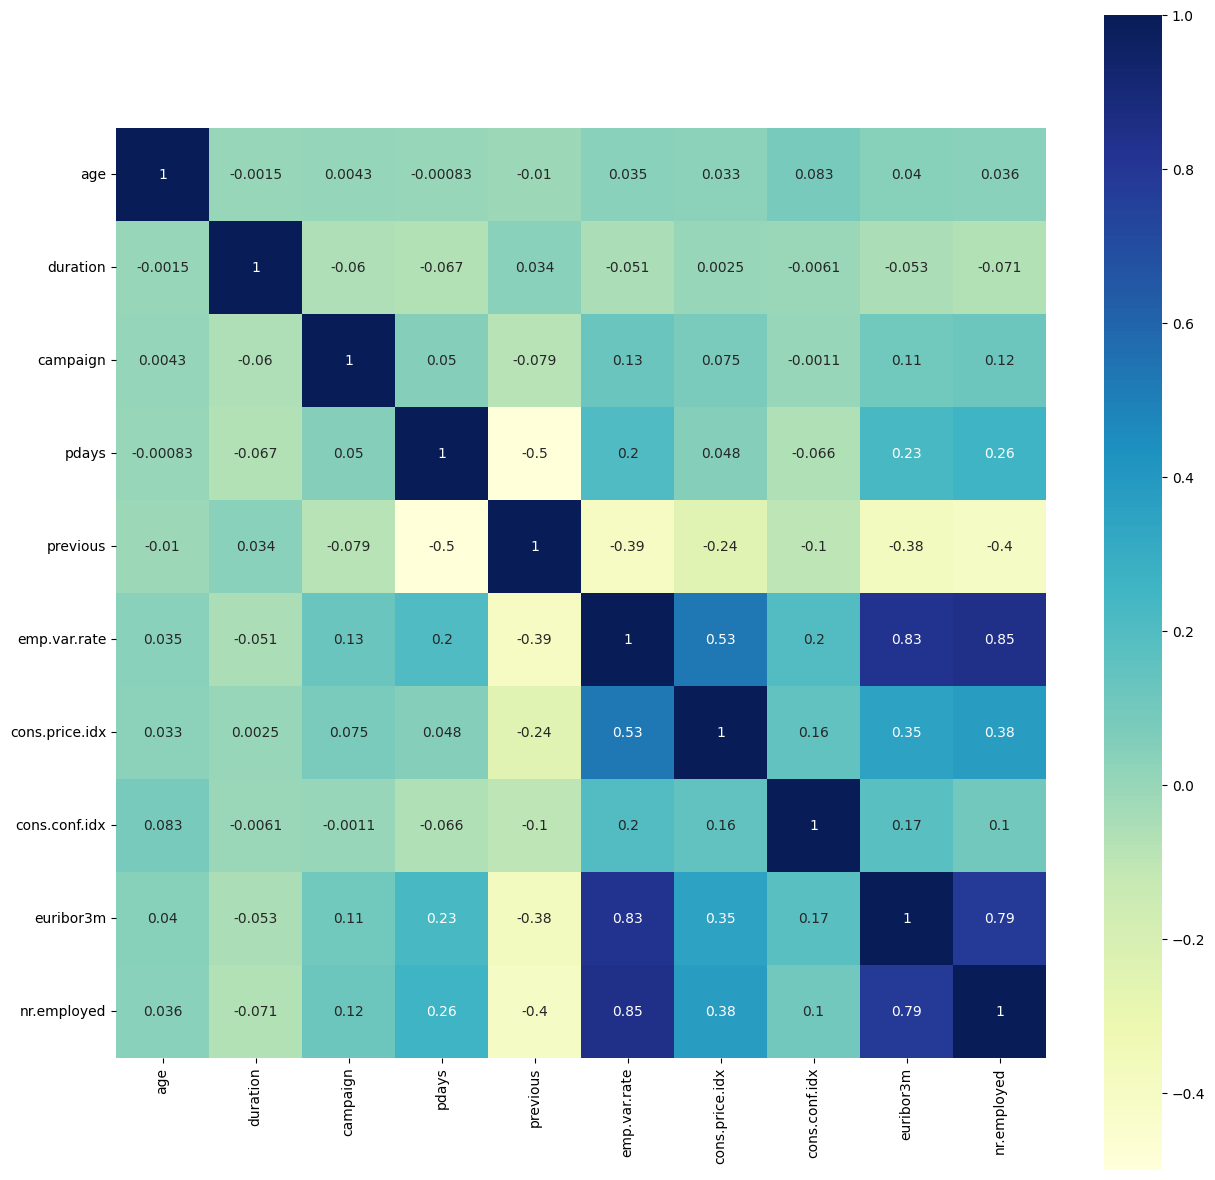

In [ ]:
cor = df.corr('kendall', numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(cor, square = True, cmap='YlGnBu', annot=True)
plt.show()

In [ ]:
df1_pca = df[['age', 'duration', 'pdays', 'previous', 'euribor3m', 'nr.employed']]
df1_pca.head()

,age,duration,pdays,previous,euribor3m,nr.employed
0,56,261,999,0,4.857,5191.0
1,57,149,999,0,4.857,5191.0
2,37,226,999,0,4.857,5191.0
3,40,151,999,0,4.857,5191.0
4,56,307,999,0,4.857,5191.0


In [ ]:
calculate_bartlett_sphericity(df1_pca)

(123946.18832592615, 0.0)

H0: Variables are unrelated (correlation matrix is an identity matrix).
As p-value < 0.05, H0 is rejected, indicating that there are statistically significant correlations between the variables. This suggests that PCA is appropriate for these data.


In [ ]:
_, kmo_model = calculate_kmo(df1_pca)
kmo_model

0.6142396139935984

KMO = 0.614, coefficient has a sufficiently high value, the data are acceptable for PCA

In [ ]:
pca1 = FactorAnalyzer(n_factors=6, rotation='varimax', method='principal')
pca1.fit(df1_pca)

FactorAnalyzer(method='principal', n_factors=6, rotation='varimax',
               rotation_kwargs={})

In [ ]:
ev, v = pca1.get_eigenvalues()
ev

array([2.60845835, 1.01547266, 0.99838146, 0.93537023, 0.39138023,
       0.05093707])

In [ ]:
def sum_eigenvalues(eigenvalues):
    return sum(eigenvalues)

total_sum = sum_eigenvalues(ev)
print("Sum of eigenvalues:", total_sum)

Sum of eigenvalues: 5.9999999999999964


In [ ]:
ev[ev > 1]

array([2.60845835, 1.01547266])

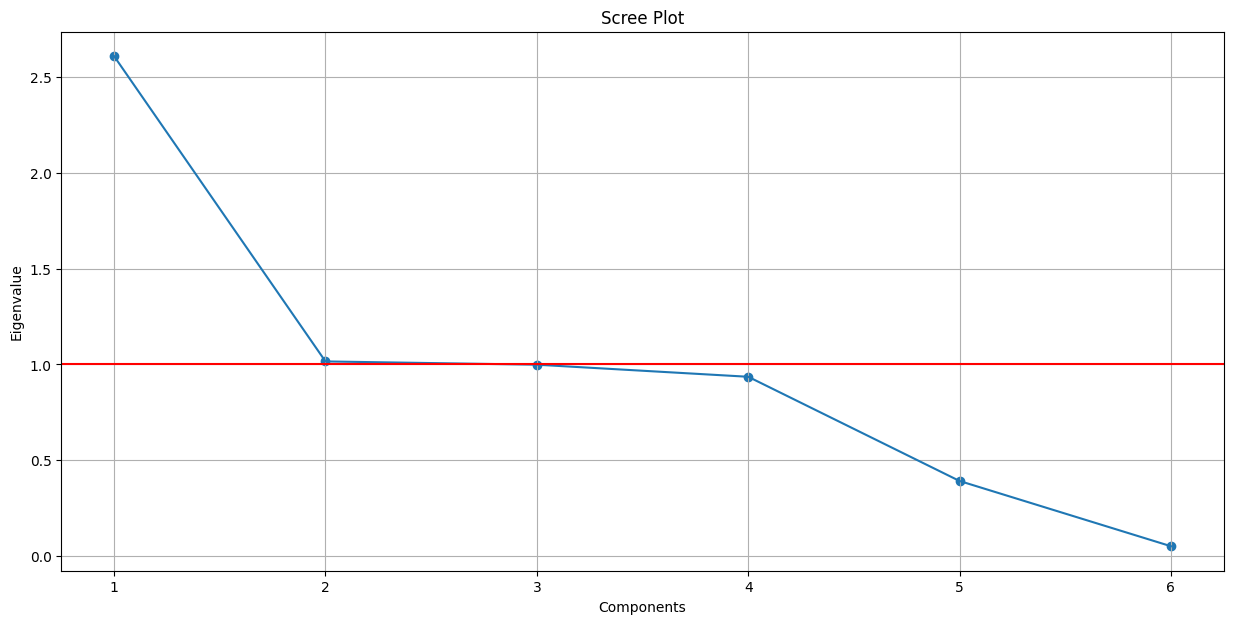

In [ ]:
plt.figure(figsize=(15, 7))
plt.scatter(range(1, df1_pca.shape[1]+1), ev)
plt.plot(range(1, df1_pca.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Components')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [ ]:
pca1 = FactorAnalyzer(n_factors=3, rotation='varimax', method='principal')
pca1.fit(df1_pca)

FactorAnalyzer(method='principal', rotation='varimax', rotation_kwargs={})

In [ ]:
pca1.loadings_

array([[-0.00433134,  0.90558673, -0.0297277 ],
       [-0.02490737, -0.02252003,  0.99248979],
       [ 0.64108465, -0.30753263, -0.11428361],
       [-0.76270288,  0.20175744,  0.03995152],
       [ 0.88129633,  0.20127345,  0.03822802],
       [ 0.91283143,  0.14232201,  0.01850206]])

In [ ]:
pca1_data = pd.DataFrame(data=pca1.loadings_,
                       index=df1_pca.columns,
                       columns=['Component_1', 'Component_2', 'Component_3'])
pca1_data

,Component_1,Component_2,Component_3
age,-0.004331,0.905587,-0.029728
duration,-0.024907,-0.022520,0.992490
pdays,0.641085,-0.307533,-0.114284
previous,-0.762703,0.201757,0.039952
euribor3m,0.881296,0.201273,0.038228
nr.employed,0.912831,0.142322,0.018502


In [ ]:
pca1_data.sort_values('Component_1', ascending=False)

,Component_1,Component_2,Component_3
nr.employed,0.912831,0.142322,0.018502
euribor3m,0.881296,0.201273,0.038228
pdays,0.641085,-0.307533,-0.114284
age,-0.004331,0.905587,-0.029728
duration,-0.024907,-0.022520,0.992490
previous,-0.762703,0.201757,0.039952


In [ ]:
pca1_data.sort_values('Component_2', ascending=False)

,Component_1,Component_2,Component_3
age,-0.004331,0.905587,-0.029728
previous,-0.762703,0.201757,0.039952
euribor3m,0.881296,0.201273,0.038228
nr.employed,0.912831,0.142322,0.018502
duration,-0.024907,-0.022520,0.992490
pdays,0.641085,-0.307533,-0.114284


In [ ]:
pca1_data.sort_values('Component_3', ascending=False)

,Component_1,Component_2,Component_3
duration,-0.024907,-0.022520,0.992490
previous,-0.762703,0.201757,0.039952
euribor3m,0.881296,0.201273,0.038228
nr.employed,0.912831,0.142322,0.018502
age,-0.004331,0.905587,-0.029728
pdays,0.641085,-0.307533,-0.114284


**Description of vairables:**
- Component_1: an economic factor that reflects the impact of employment and interest rates. The higher the value of the component, the more stable the customer's economic environment is, which may increase their propensity to subscribe to deposit.

- Component_2: demographic factor related to age and history of interactions.  The higher the component value, the older the customer is and the more interaction histories they have, which may reflect their experience with the bank.

- Component_3: customer engagement as determined by the duration of last contact. The higher the value of the component, the longer the duration of the last contact, which may indicate a higher interest of the client in the bank's products.

In [ ]:
pca1.get_communalities()

array([0.82098983, 0.98616351, 0.51862658, 0.62401787, 0.8186556 ,
       0.85385909])

In [ ]:
communalities1 = pd.DataFrame(data=pca1.get_communalities(),
                       index=df1_pca.columns,
                       columns=['Communalities'])
communalities1.sort_values('Communalities')

,Communalities
pdays,0.518627
previous,0.624018
euribor3m,0.818656
age,0.820990
nr.employed,0.853859
duration,0.986164


In [ ]:
communalities1[communalities1.Communalities < 0.3]

,Communalities


In [ ]:
cumulative_variances = pca1.get_factor_variance()[2]
cumulative_variances

array([0.43388146, 0.60332203, 0.77038541])

In [ ]:
factor_variance = pd.DataFrame(data=pca1.get_factor_variance()[1:3],
                              index=['Proportional variance', 'Cumulative variance'],
                              columns=pca1_data.columns)
factor_variance

,Component_1,Component_2,Component_3
Proportional variance,0.433881,0.169441,0.167063
Cumulative variance,0.433881,0.603322,0.770385


In [ ]:
# Formation of a table with the obtained components
transformed = pd.DataFrame(data=pca1.transform(df1_pca), index=df1_pca.index, columns=pca1_data.columns)
transformed

,Component_1,Component_2,Component_3
0,0.531485,1.448984,-0.002950
1,0.524317,1.545506,-0.434472
2,0.504230,-0.173029,-0.077755
3,0.502449,0.090968,-0.373966
4,0.534961,1.444478,0.173005
...,...,...,...
41183,-1.317857,1.932738,-0.060342
41184,-1.349126,-0.381901,0.211036
41185,-1.350833,0.492601,-0.562128
41186,-1.347259,-0.558780,0.442936


In [ ]:
# Adding the received components to the dataset
df_dummies = pd.concat([df_dummies, transformed], axis=1)

### Hypotesis

- H0: None of the factors - economic stability (Component_1), age and interaction history (Component_2), customer engagement (Component_3), previous campaign outcome (poutcome), education level (education), and marital status (marital) - affect a customer's likelihood of signing up for a deposit (y).

- H1: One or more factors - economic stability (Component_1), age and interaction history (Component_2), customer engagement (Component_3), previous campaign outcome (poutcome), education level (education), or marital status (marital) - affect a customer's likelihood of signing up for a deposit (y).

### Binary Logistic Regression Model

In [ ]:
# Получение списка всех столбцов, начинающихся с "age"
age_columns = [col for col in df_dummies.columns if col.startswith('poutcome')]

# Выводим результат
print(age_columns)

['poutcome_failure', 'poutcome_nonexistent', 'poutcome_success']


In [ ]:
df_model1 = df_dummies.dropna(subset=[
'Component_1', 'Component_2', 'Component_3',
'education_basic.4y', 'education_basic.6y', 'education_basic.9y',
'education_high.school', 'education_professional.course',
'marital_divorced', 'marital_single',
'poutcome_failure', 'poutcome_success', 'y'])
df_model1.shape

(39368, 33)

In [ ]:
x_mult = df_model1[['Component_1', 'Component_2', 'Component_3',
'education_basic.4y', 'education_basic.6y', 'education_basic.9y',
'education_high.school', 'education_professional.course',
'marital_divorced', 'marital_single',
'poutcome_failure', 'poutcome_success']]
y = df_model1['y']
x_mult_constant = sm.add_constant(x_mult)

In [ ]:
model1 = sm.Logit(y, x_mult_constant).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.224978
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                39368
Model:                          Logit   Df Residuals:                    39355
Method:                           MLE   Df Model:                           12
Date:                Sat, 09 Nov 2024   Pseudo R-squ.:                  0.3551
Time:                        18:14:58   Log-Likelihood:                -8856.9
converged:                       True   LL-Null:                       -13734.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -2.4354      0.042    -58.138      0.

In [ ]:
coefs = pd.DataFrame()
coefs['Coefs'] = model1.params[1:]
coefs['Features'] = model1.params.index[1:]
coefs.set_index('Features', inplace=True)
print('Intercept = ', model1.params[0])
coefs

Intercept =  -2.4354470513289264


,Coefs
Features,
Component_1,-1.531444
Component_2,0.028960
Component_3,1.157550
education_basic.4y,-0.303194
education_basic.6y,-0.495663
education_basic.9y,-0.571679
education_high.school,-0.319084
education_professional.course,-0.151318
marital_divorced,0.063142


In [ ]:
coefs['OddsRatio'] = np.exp(coefs.Coefs)
coefs

,Coefs,OddsRatio
Features,,
Component_1,-1.531444,0.216223
Component_2,0.028960,1.029384
Component_3,1.157550,3.182128
education_basic.4y,-0.303194,0.738456
education_basic.6y,-0.495663,0.609167
education_basic.9y,-0.571679,0.564577
education_high.school,-0.319084,0.726814
education_professional.course,-0.151318,0.859574
marital_divorced,0.063142,1.065178


In [ ]:
def yes_no(p_value, level = 0.05):
    if abs(p_value) < level:
        return 'significant'
    else:
        return 'non-significant'

In [ ]:
pvals = pd.DataFrame()
pvals['p_values'] = model1.pvalues[1:]
pvals['5% level']= pvals['p_values'].apply(yes_no)
pvals['p_values'] = pvals['p_values'].map('{:.3f}'.format)
pvals['Features'] = model1.params.index[1:]
pvals.set_index('Features',inplace=True)
pvals

,p_values,5% level
Features,,
Component_1,0.000,significant
Component_2,0.205,non-significant
Component_3,0.000,significant
education_basic.4y,0.000,significant
education_basic.6y,0.000,significant
education_basic.9y,0.000,significant
education_high.school,0.000,significant
education_professional.course,0.019,significant
marital_divorced,0.347,non-significant


In [ ]:
pvals['10% level'] = model1.pvalues[1:].apply(lambda x: yes_no(x, level=0.1))
pvals

,p_values,5% level,10% level
Features,,,
Component_1,0.000,significant,significant
Component_2,0.205,non-significant,non-significant
Component_3,0.000,significant,significant
education_basic.4y,0.000,significant,significant
education_basic.6y,0.000,significant,significant
education_basic.9y,0.000,significant,significant
education_high.school,0.000,significant,significant
education_professional.course,0.019,significant,significant
marital_divorced,0.347,non-significant,non-significant


### Model Characteristics

In [ ]:
print('R^2 = {:f}'.format(model1.prsquared))
print('Model significance = {:f}'.format(model1.llr_pvalue))

R^2 = 0.355130
Model significance = 0.000000


In [ ]:
f'Statistically significant model parameters: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Statistically significant model parameters: ['const' 'Component_1' 'Component_3' 'education_basic.4y'\n 'education_basic.6y' 'education_basic.9y' 'education_high.school'\n 'education_professional.course' 'marital_single' 'poutcome_failure'\n 'poutcome_success']"

In [ ]:
f'Statistically nonsignificant model parameters: {model1.pvalues[model1.pvalues > 0.05].index.values}'

"Statistically nonsignificant model parameters: ['Component_2' 'marital_divorced']"

In [ ]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('logit(p) = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

logit(p) = -2.435447 + -1.53*Component_1 + 0.03*Component_2 + 1.16*Component_3 + -0.30*education_basic.4y + -0.50*education_basic.6y + -0.57*education_basic.9y + -0.32*education_high.school + -0.15*education_professional.course + 0.06*marital_divorced + 0.10*marital_single + -1.72*poutcome_failure + -2.13*poutcome_success


### Regression coefficients interpretation ###

- Component_1 (-1.53): For each unit increase in economic stability (Component_1), the log-odds of a client subscribing to a deposit decrease by 1.53, indicating that higher economic stability is associated with a lower likelihood of subscription.

- Component_2 (0.03): The coefficient for Component_2 is positive but very small and statistically insignificant, suggesting that age and history of interactions have little to no effect on the likelihood of subscription.

- Component_3 (1.16): Each additional unit of customer engagement (Component_3), which reflects the duration of the last contact, increases the log-odds of subscription by 1.16, indicating that more engaged clients are more likely to subscribe.

- education_basic.4y (-0.30): Clients with basic education (4 years) have a decrease of 0.30 in the log-odds of subscribing compared to the reference education group (likely higher education).

- education_basic.6y (-0.50): Clients with basic education (6 years) see a decrease in log-odds of 0.50, suggesting lower likelihood of subscribing compared to the reference group.

- education_basic.9y (-0.57): Basic education (9 years) further reduces the log-odds of subscription by 0.57, indicating a similar trend as the previous categories.

- education_high.school (-0.32): High school education is associated with a decrease in log-odds by 0.32, suggesting lower likelihood of subscription compared to the reference education group.

- education_professional.course (-0.15): Clients with professional course education show a slight decrease in log-odds of 0.15, indicating a marginally lower likelihood of subscription than the reference group.

- marital_divorced (0.06): Divorced clients have a very slight increase in the log-odds of subscribing by 0.06, although this effect is not statistically significant.

- marital_single (0.10): Single clients show a slight increase in the log-odds of subscription by 0.10, suggesting a marginally higher likelihood of subscribing compared to the reference marital group.

- poutcome_failure (-1.72): Clients with a previous campaign outcome of "failure" see a decrease in log-odds of subscription by 1.72, indicating they are less likely to subscribe.

- poutcome_success (-2.13): Clients with a previous successful campaign outcome have a decrease in log-odds of 2.13, suggesting they are also less likely to subscribe, potentially because they have already subscribed before.

## Confusion matrix

In [ ]:
cm = model1.pred_table()
cm

array([[34152.,   841.],
       [ 2863.,  1512.]])

In [ ]:
print('TP: {} | FN: {}\n-------------------\nFP: {}  | TN: {}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

TP: 34152.0 | FN: 841.0
-------------------
FP: 2863.0  | TN: 1512.0


In [ ]:
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))
print('Accuracy: {}'.format(accuracy))

Accuracy: 0.9059134322292217


In [ ]:
fpr, tpr, _ = roc_curve(df_model1['y'], model1.predict())
roc_auc = auc(fpr, tpr)

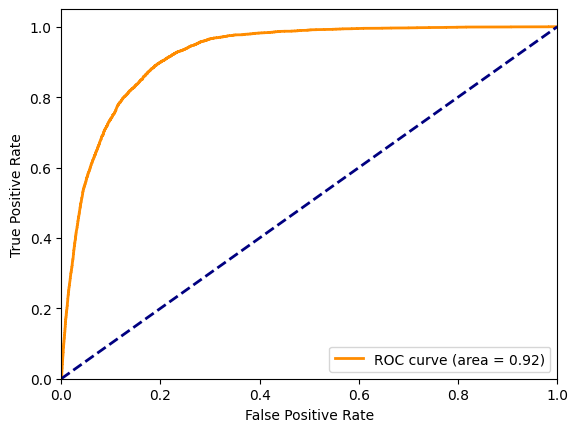

In [ ]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

## Model Diagnostics

In [ ]:
p = stats.kstest(model1.resid_generalized, 'norm', args=(model1.resid_generalized.mean(), model1.resid_generalized.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


<Axes: ylabel='Density'>

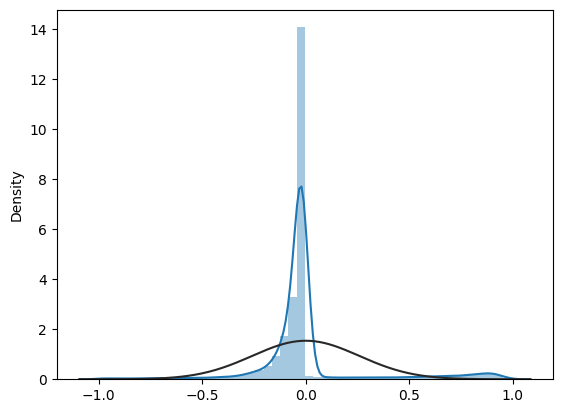

In [ ]:
sns.distplot(model1.resid_generalized, fit=stats.norm)

In [ ]:
vifs = np.array([vif(model1.model.exog, i) for i in range(model1.model.exog.shape[1])])

In [ ]:
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model1.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
2,1.022255,Component_3
8,1.067203,marital_divorced
4,1.136403,education_basic.6y
7,1.247117,education_professional.course
9,1.271190,marital_single
3,1.281475,education_basic.4y
5,1.288600,education_basic.9y
6,1.358152,education_high.school
1,1.519139,Component_2
10,1.669205,poutcome_failure


In [ ]:
df_model1['probability'] = model1.predict()
df_model1

,age,job,default,housing,loan,contact,month,day_of_week,duration,campaign,...,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,Component_1,Component_2,Component_3,probability
0,56.0,housemaid,no,no,no,telephone,may,mon,261.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.531485,1.448984,-0.002950,0.028916
1,57.0,services,unknown,no,no,telephone,may,mon,149.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.524317,1.545506,-0.434472,0.017712
2,37.0,services,no,yes,no,telephone,may,mon,226.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.504230,-0.173029,-0.077755,0.026040
3,40.0,admin.,no,no,no,telephone,may,mon,151.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.502449,0.090968,-0.373966,0.015815
4,56.0,services,no,no,yes,telephone,may,mon,307.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.534961,1.444478,0.173005,0.034500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73.0,retired,no,yes,no,cellular,nov,fri,334.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.317857,1.932738,-0.060342,0.358376
41184,46.0,blue-collar,no,no,no,cellular,nov,fri,383.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.349126,-0.381901,0.211036,0.428633
41185,56.0,retired,no,yes,no,cellular,nov,fri,189.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,-1.350833,0.492601,-0.562128,0.268323
41186,44.0,technician,no,no,no,cellular,nov,fri,442.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.347259,-0.558780,0.442936,0.493256


In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(0)
x_train, x_test, y_train, y_test = train_test_split(x_mult, y, test_size = 0.2, random_state = 0)
x_train

,Component_1,Component_2,Component_3,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,marital_divorced,marital_single,poutcome_failure,poutcome_success
6884,0.478410,-1.186299,-0.560661,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6307,0.528390,-0.378809,1.282554,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690,0.505320,0.087245,-0.228612,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25958,0.364616,-0.493236,-0.750504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33600,-1.252555,-0.681658,-0.702026,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
21775,0.722749,1.470952,-0.523444,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
33505,-0.646704,0.224949,-0.671366,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
31768,-0.657173,-1.056211,-0.531599,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
22265,0.750630,0.562135,1.584648,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
x_test

,Component_1,Component_2,Component_3,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,marital_divorced,marital_single,poutcome_failure,poutcome_success
26964,0.361192,-0.331085,-0.620640,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
15389,0.689744,-0.582415,-0.475858,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
33656,-1.256710,-0.505618,-0.949595,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
28185,-0.626342,-1.048233,-0.232420,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
13659,0.711941,0.001692,0.106967,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12823,0.757717,0.814252,1.747413,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
37622,-1.439863,-1.321156,0.212093,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2917,0.499780,-0.253727,-0.254353,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8794,0.687103,0.694811,-0.728581,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
y_train

,y
6884,0.0
6307,0.0
690,0.0
25958,0.0
33600,0.0
...,...
21775,0.0
33505,0.0
31768,0.0
22265,0.0


In [ ]:
y_test

,y
26964,0.0
15389,0.0
33656,0.0
28185,0.0
13659,0.0
...,...
12823,1.0
37622,1.0
2917,0.0
8794,0.0


In [ ]:
model_train = sm.Logit(y_train, x_train).fit()
print(model_train.summary())

Optimization terminated successfully.
         Current function value: 0.285617
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                31494
Model:                          Logit   Df Residuals:                    31482
Method:                           MLE   Df Model:                           11
Date:                Sat, 09 Nov 2024   Pseudo R-squ.:                  0.1833
Time:                        18:29:45   Log-Likelihood:                -8995.2
converged:                       True   LL-Null:                       -11015.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Component_1                      -1.6231      0.030    -53.461      0.

In [ ]:
cm = model_train.pred_table()
cm

array([[26265.,  1716.],
       [ 1855.,  1658.]])

In [ ]:
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))
print('Accuracy of the train model: {}'.format(accuracy))

Accuracy of the train model: 0.8866133231726678


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)
test_predicated = lr.predict(x_test)

In [ ]:
cm = pd.crosstab(y_test, test_predicated)
print(cm)

col_0   0.0  1.0
y               
0.0    6855  157
1.0     545  317


In [ ]:
accuracy = (cm[0][0] + cm[1][1]) / len(y_test)
print('Accuracy of the test model: {}'.format(accuracy))

Accuracy of the test model: 0.9108458216916434


## Conclusions About the Results of Analysis

The constructed logistic regression model for predicting the probability of customer subscription to deposit shows high efficiency and stability. The analysis confirms the significance of the influence of factors such as economic stability (Component_1), customer engagement (Component_3), education level, marital status and outcome of previous campaign on the probability of subscription. Thus, the null hypothesis assuming no influence of these factors was rejected and it was confirmed that one or more factors do have a significant influence on a customer's subscription probability.

The accuracy of the model on the training sample is 88.66% and on the test sample is 91.08%, indicating good generalization ability of the model and no evidence of overtraining. The high AUC value (0.92) further confirms that the model effectively distinguishes between customers who are prone and those who are not prone to subscribe.